# Book - Modern Time Series Forecasting with Python

## Chapter 12 - Multivariate Time Series Forecasting


### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.23.5
* sklearn: 1.3.2
* seaborn: 0.13.2
* statsmodels: 0.14.1
* tensorflow: 2.12.0
* keras: 2.12.0

### Loading libraries

In [83]:
import warnings
warnings.filterwarnings('ignore') 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input,Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

In [2]:
# Some ops (like tf.split) create implicit TF1 placeholders in graph mode. 
# Enforcing eager execution prevents these and stops the kernel from crashing.
tf.config.run_functions_eagerly(True)

### <span style="color:blue">01.Using CNNs for Time Series Feature Extraction

#### Load dataset and visualize

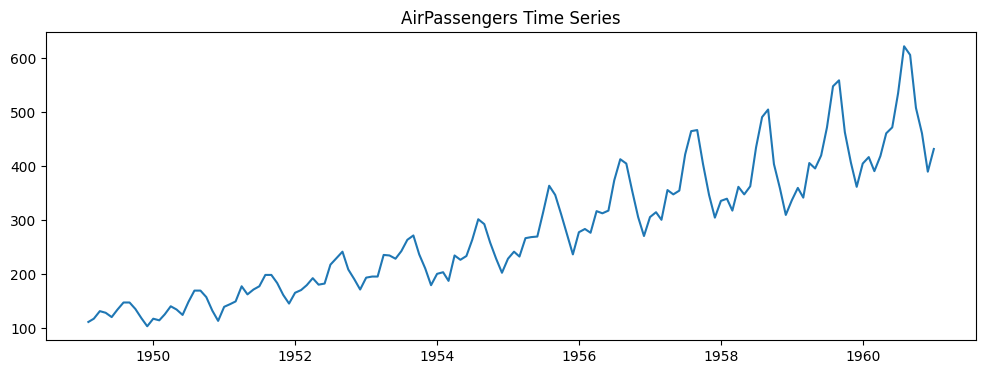

In [9]:
# Load dataset
data = sm.datasets.get_rdataset("AirPassengers", "datasets", cache=True).data
ts = data['value']
ts.index = pd.date_range(start='1949-01', periods=len(ts), freq='M')

plt.figure(figsize=(12,4))
plt.plot(ts)
plt.title("AirPassengers Time Series")
plt.show()

#### Train-Test Split & Scaling

In [10]:
values = ts.values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

train_size = int(len(scaled) * 0.8)
train, test = scaled[:train_size], scaled[train_size:]

#### Create supervised learning sequences

In [12]:
def create_sequences(data, n_timesteps=12):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:i+n_timesteps])
        y.append(data[i+n_timesteps])
    return np.array(X), np.array(y)

n_timesteps = 12
n_features = 1

X_train, y_train = create_sequences(train, n_timesteps)
X_test, y_test = create_sequences(test, n_timesteps)

# this is important before we proceed 
print("Training shape:", X_train.shape, "Testing shape:", X_test.shape)

Training shape: (103, 12, 1) Testing shape: (17, 12, 1)


#### Build 1D CNN model for feature extraction

In [13]:
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(n_timesteps, n_features), name="Conv1D_1"),
    MaxPooling1D(pool_size=2, name="MaxPool_1"),
    Dropout(0.2),
    
    Conv1D(filters=32, kernel_size=3, activation='relu', name="Conv1D_2"),
    Flatten(),
    
    Dense(32, activation='relu', name="Dense_1"),
    Dense(1, activation='linear', name="Output")
], name="CNN_TimeSeries_Model")

cnn_model.summary()

cnn_model.compile(optimizer='adam', loss='mse')

2025-12-09 18:15:05.153656: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-09 18:15:05.153784: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "CNN_TimeSeries_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Conv1D_1 (Conv1D)           (None, 10, 64)            256       
                                                                 
 MaxPool_1 (MaxPooling1D)    (None, 5, 64)             0         
                                                                 
 dropout (Dropout)           (None, 5, 64)             0         
                                                                 
 Conv1D_2 (Conv1D)           (None, 3, 32)             6176      
                                                                 
 flatten (Flatten)           (None, 96)                0         
                                                                 
 Dense_1 (Dense)             (None, 32)                3104      
                                                                 
 Output (Dense)              (None, 1)        

#### Train model

In [14]:
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50


2025-12-09 18:15:24.403184: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-12-09 18:15:24.474159: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_10.


6/6 [==============================] - ETA: 0s - loss: 0.0888 

2025-12-09 18:15:27.525024: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


6/6 [==============================] - 4s 216ms/step - loss: 0.0888 - val_loss: 0.0622
Epoch 2/50
6/6 [==============================] - 0s 17ms/step - loss: 0.0124 - val_loss: 0.0192
Epoch 3/50
6/6 [==============================] - 0s 15ms/step - loss: 0.0158 - val_loss: 0.0155
Epoch 4/50
6/6 [==============================] - 0s 16ms/step - loss: 0.0093 - val_loss: 0.0134
Epoch 5/50
6/6 [==============================] - 0s 15ms/step - loss: 0.0071 - val_loss: 0.0183
Epoch 6/50
6/6 [==============================] - 0s 16ms/step - loss: 0.0078 - val_loss: 0.0140
Epoch 7/50
6/6 [==============================] - 0s 15ms/step - loss: 0.0060 - val_loss: 0.0108
Epoch 8/50
6/6 [==============================] - 0s 15ms/step - loss: 0.0060 - val_loss: 0.0113
Epoch 9/50
6/6 [==============================] - 0s 15ms/step - loss: 0.0062 - val_loss: 0.0107
Epoch 10/50
6/6 [==============================] - 0s 15ms/step - loss: 0.0055 - val_loss: 0.0103
Epoch 11/50
6/6 [======================

#### Evaluate model performance

2025-12-09 18:16:16.484289: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 297ms/step


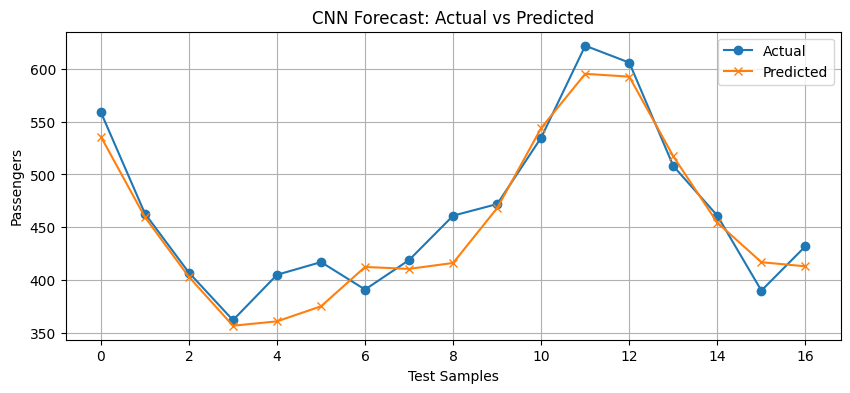

In [15]:
y_pred = cnn_model.predict(X_test)

# Inverse scale
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

plt.figure(figsize=(10,4))
plt.plot(y_test_inv, label="Actual", marker='o')
plt.plot(y_pred_inv, label="Predicted", marker='x')
plt.title("CNN Forecast: Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

#### Visualize learned CNN feature maps

1/1 [==============================] - 0s 114ms/step


2025-12-09 18:16:47.712710: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Feature map shape: (1, 10, 64)


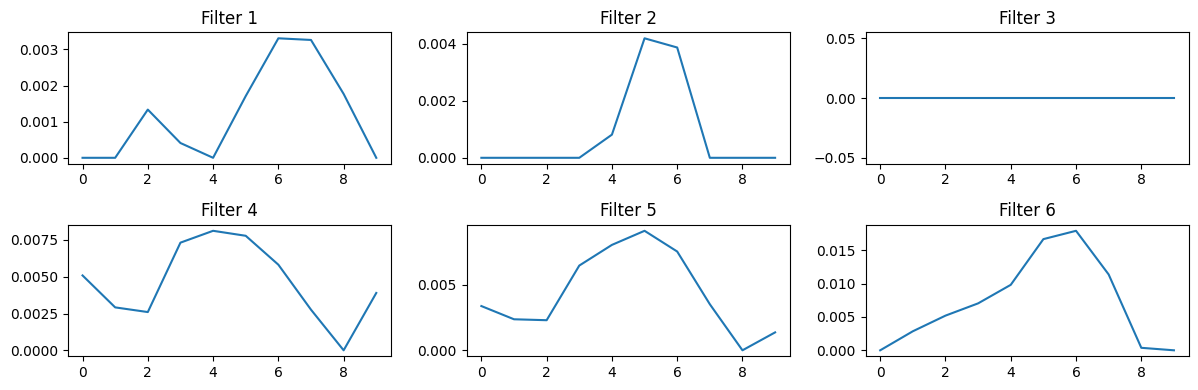

In [16]:
extractor = tf.keras.Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.get_layer("Conv1D_1").output
)

feature_maps = extractor.predict(X_train[:1])

print("Feature map shape:", feature_maps.shape)

# Plot first few feature maps
num_filters = feature_maps.shape[-1]
plt.figure(figsize=(12, 4))

for i in range(min(6, num_filters)):
    plt.subplot(2, 3, i+1)
    plt.plot(feature_maps[0, :, i])
    plt.title(f"Filter {i+1}")
plt.tight_layout()
plt.show()

### <span style="color:blue">02. Hybrid CNN-LSTM (ConvLSTM1D)

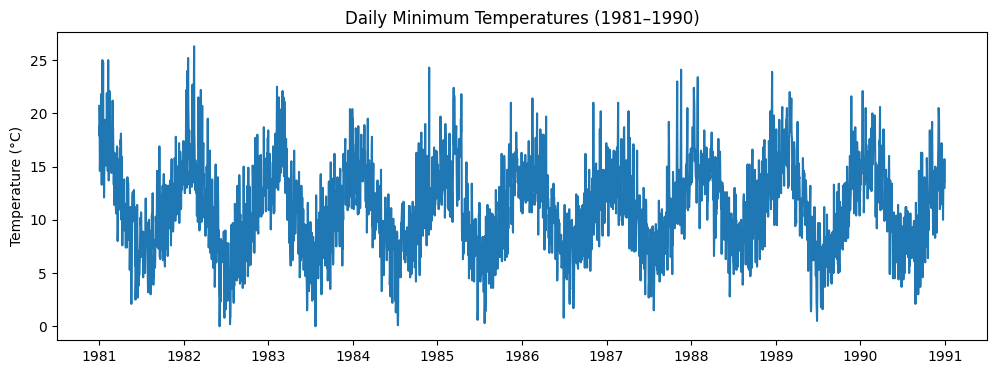

In [3]:
# url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv("./daily-min-temperatures.csv", parse_dates=['Date'], index_col='Date')
ts = df['Temp']

plt.figure(figsize=(12,4))
plt.plot(ts)
plt.title("Daily Minimum Temperatures (1981–1990)")
plt.ylabel("Temperature (°C)")
plt.show()


#### Scaling + Train/Test Split

In [4]:
values = ts.values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

train_size = int(len(scaled) * 0.8)
train, test = scaled[:train_size], scaled[train_size:]


#### Create Windowed Sequences

In [5]:
def create_sequences(data, n_timesteps=30):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:i+n_timesteps])
        y.append(data[i+n_timesteps])
    return np.array(X), np.array(y)

n_timesteps = 30  # 30 days
n_features = 1

X_train, y_train = create_sequences(train, n_timesteps)
X_test, y_test = create_sequences(test, n_timesteps)

print("Shapes:", X_train.shape, X_test.shape)

Shapes: (2890, 30, 1) (700, 30, 1)


#### Hybrid CNN–LSTM Model

In [6]:
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation="relu",
           input_shape=(n_timesteps, n_features), name="Conv1D_1"),
    MaxPooling1D(pool_size=2, name="MaxPool_1"),
    Dropout(0.2),
    
    Conv1D(filters=32, kernel_size=3, activation="relu", name="Conv1D_2"),
    MaxPooling1D(pool_size=2, name="MaxPool_2"),
    Dropout(0.2),

    # Flatten CNN output so LSTM can process time features
    Flatten(),

    # LSTM layer — learns long-term dependencies
    tf.keras.layers.Reshape((1, -1)),  # Convert back to (timesteps, features)
    LSTM(50, activation="tanh", name="LSTM_1"),
    
    Dense(32, activation="relu"),
    Dense(1, activation="linear", name="Output_Layer")
])

model.summary()
model.compile(optimizer="adam", loss="mse")

2025-12-09 18:32:41.881707: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-09 18:32:41.881943: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Conv1D_1 (Conv1D)           (None, 28, 64)            256       
                                                                 
 MaxPool_1 (MaxPooling1D)    (None, 14, 64)            0         
                                                                 
 dropout (Dropout)           (None, 14, 64)            0         
                                                                 
 Conv1D_2 (Conv1D)           (None, 12, 32)            6176      
                                                                 
 MaxPool_2 (MaxPooling1D)    (None, 6, 32)             0         
                                                                 
 dropout_1 (Dropout)         (None, 6, 32)             0         
                                                                 
 flatten (Flatten)           (None, 192)               0

2025-12-09 18:32:42.462703: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-09 18:32:42.464005: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-09 18:32:42.464843: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

#### Train the Model

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
82/82 [==============================] - 12s 115ms/step - loss: 0.0283 - val_loss: 0.0123
Epoch 2/50
82/82 [==============================] - 7s 90ms/step - loss: 0.0134 - val_loss: 0.0139
Epoch 3/50
82/82 [==============================] - 7s 85ms/step - loss: 0.0127 - val_loss: 0.0167
Epoch 4/50
82/82 [==============================] - 7s 90ms/step - loss: 0.0123 - val_loss: 0.0144
Epoch 5/50
82/82 [==============================] - 8s 96ms/step - loss: 0.0123 - val_loss: 0.0148
Epoch 6/50
82/82 [==============================] - 7s 91ms/step - loss: 0.0117 - val_loss: 0.0134
Epoch 7/50
82/82 [==============================] - 7s 88ms/step - loss: 0.0111 - val_loss: 0.0111
Epoch 8/50
82/82 [==============================] - 7s 88ms/step - loss: 0.0117 - val_loss: 0.0110
Epoch 9/50
82/82 [==============================] - 7s 91ms/step - loss: 0.0109 - val_loss: 0.0154
Epoch 10/50
82/82 [==============================] - 8s 100ms/step - loss: 0.0110 - val_loss: 0.0153
Epoch 

#### Predictions

22/22 [==============================] - 0s 14ms/step


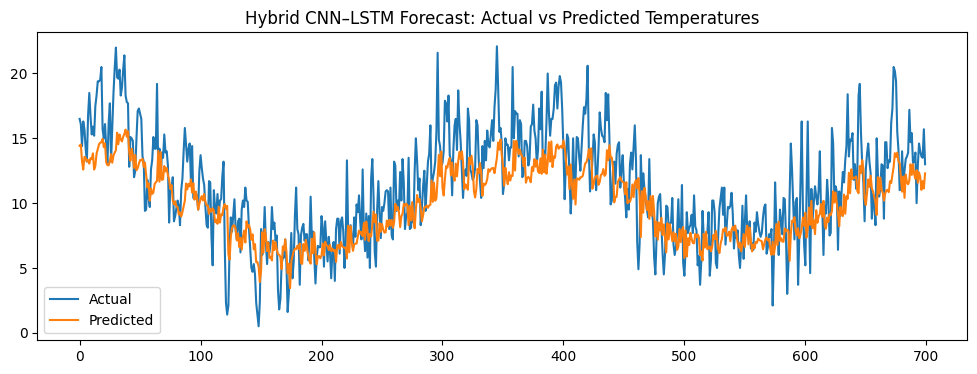

In [12]:
y_pred = model.predict(X_test)

# Inverse scaling
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="Actual", linestyle='-')
plt.plot(y_pred_inv, label="Predicted", linestyle='-')
plt.title("Hybrid CNN–LSTM Forecast: Actual vs Predicted Temperatures")
plt.legend()
#plt.grid(True)
plt.show()

#### Loss Curve

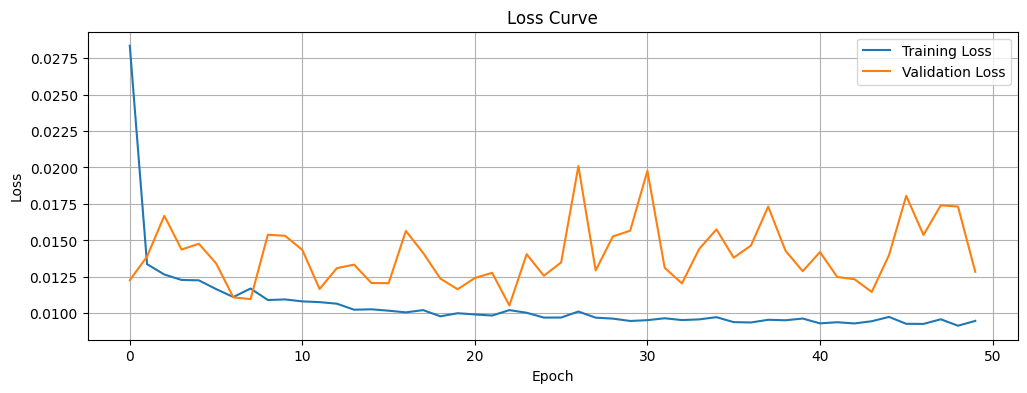

In [14]:
plt.figure(figsize=(12,4))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


### <span style="color:blue">03. Encoder–Decoder (Seq2Seq) LSTM for Multi-Step Forecasting

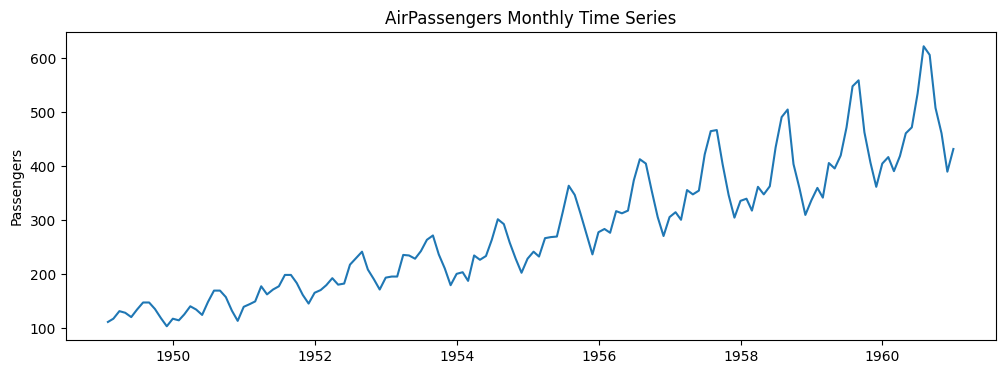

In [24]:
# Load dataset
data = sm.datasets.get_rdataset("AirPassengers", "datasets", cache=True).data
ts = data['value']
ts.index = pd.date_range(start='1949-01', periods=len(ts), freq='M')

plt.figure(figsize=(12,4))
plt.plot(ts)
plt.title("AirPassengers Monthly Time Series")
plt.ylabel("Passengers")
plt.show()

#### Scaling

In [25]:
values = ts.values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

#### Create supervised learning sequences for Seq2Seq

In [26]:
def create_seq2seq_data(data, input_steps=24, output_steps=12):
    X, y = [], []
    for i in range(len(data) - input_steps - output_steps):
        X.append(data[i:i+input_steps])
        y.append(data[i+input_steps:i+input_steps+output_steps])
    return np.array(X), np.array(y)

INPUT_STEPS = 24
OUTPUT_STEPS = 12
FEATURES = 1

X, y = create_seq2seq_data(scaled, INPUT_STEPS, OUTPUT_STEPS)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Training shape:", X_train.shape, "Testing shape:", X_test.shape)

Training shape: (86, 24, 1) Testing shape: (22, 24, 1)


#### Build Encoder–Decoder Seq2Seq Model

In [29]:
LATENT_DIM = 64

# Encoder
encoder_inputs = Input(shape=(INPUT_STEPS, FEATURES))
encoder_lstm = LSTM(LATENT_DIM, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(OUTPUT_STEPS, FEATURES))
decoder_lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=False)
decoder_outputs = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(1)
decoder_outputs = decoder_dense(decoder_outputs)

# Full Seq2Seq Model
seq2seq_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.summary()

seq2seq_model.compile(optimizer="adam", loss="mse")

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 24, 1)]      0           []                               
                                                                                                  
 input_4 (InputLayer)           [(None, 12, 1)]      0           []                               
                                                                                                  
 lstm_2 (LSTM)                  [(None, 64),         16896       ['input_3[0][0]']                
                                 (None, 64),                                                      
                                 (None, 64)]                                                      
                                                                                              

2025-12-09 18:56:45.165059: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-09 18:56:45.165994: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-09 18:56:45.166974: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

#### Prepare Decoder Inputs

In [30]:
# Use previous true values as decoder inputs
decoder_input_data = np.zeros_like(y_train)
decoder_input_data[:, 1:, :] = y_train[:, :-1, :]  # shift right
decoder_input_data[:, 0, :] = X_train[:, -1, :]    # first decoder input = last encoder input

decoder_input_test = np.zeros_like(y_test)
decoder_input_test[:, 1:, :] = y_test[:, :-1, :]
decoder_input_test[:, 0, :] = X_test[:, -1, :]

#### Train Model

In [31]:
history = seq2seq_model.fit(
    [X_train, decoder_input_data], y_train,
    epochs=80,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/80
5/5 [==============================] - 3s 308ms/step - loss: 0.0835 - val_loss: 0.1181
Epoch 2/80
5/5 [==============================] - 0s 89ms/step - loss: 0.0245 - val_loss: 0.0200
Epoch 3/80
5/5 [==============================] - 0s 86ms/step - loss: 0.0124 - val_loss: 0.0234
Epoch 4/80
5/5 [==============================] - 0s 92ms/step - loss: 0.0115 - val_loss: 0.0166
Epoch 5/80
5/5 [==============================] - 0s 92ms/step - loss: 0.0080 - val_loss: 0.0263
Epoch 6/80
5/5 [==============================] - 0s 97ms/step - loss: 0.0092 - val_loss: 0.0253
Epoch 7/80
5/5 [==============================] - 0s 96ms/step - loss: 0.0081 - val_loss: 0.0182
Epoch 8/80
5/5 [==============================] - 0s 96ms/step - loss: 0.0071 - val_loss: 0.0150
Epoch 9/80
5/5 [==============================] - 1s 102ms/step - loss: 0.0072 - val_loss: 0.0151
Epoch 10/80
5/5 [==============================] - 0s 104ms/step - loss: 0.0068 - val_loss: 0.0159
Epoch 11/80
5/5 [=========

#### Predict Next 12 Months

In [32]:
y_pred = seq2seq_model.predict([X_test, decoder_input_test])

# Inverse-scale predictions
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape)


1/1 [==============================] - 0s 191ms/step


#### Plot One Forecast Example

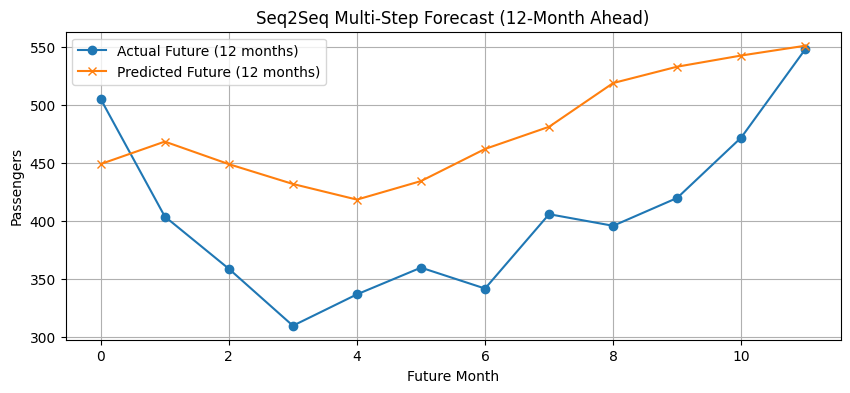

In [33]:
sample = 5  # pick some test sample

plt.figure(figsize=(10,4))
plt.plot(y_test_inv[sample], label="Actual Future (12 months)", marker='o')
plt.plot(y_pred_inv[sample], label="Predicted Future (12 months)", marker='x')
plt.title("Seq2Seq Multi-Step Forecast (12-Month Ahead)")
plt.xlabel("Future Month")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)
plt.show()

#### Loss Curve

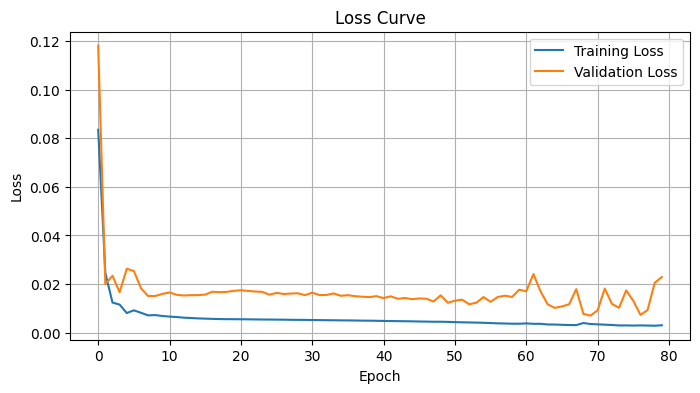

In [34]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

### <span style="color:blue">04. Multivariate Deep Learning Models LSTM

####  Loading and visualize Dataset

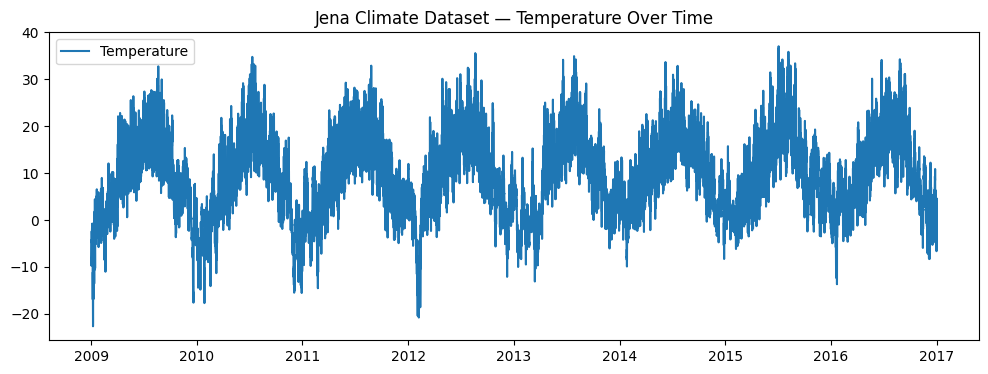

In [47]:
# url = "https://raw.githubusercontent.com/PacktPublishing/Deep-Learning-with-TensorFlow-2.0-in-7-Steps/refs/heads/master/Section%205/temperature/jena_climate_2009_2016.csv"

df = pd.read_csv("./jena_climate_2009_2016.csv")

# Convert and index
df['Date Time'] = pd.to_datetime(df['Date Time'],format="%d.%m.%Y %H:%M:%S")
df = df.set_index('Date Time')

# Select 5 features
features = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'wd (deg)']
data = df[features].resample('H').mean()


# FIX: handle NaNs
data = data.interpolate().fillna(method='bfill').fillna(method='ffill')


# Plot
plt.figure(figsize=(12,4))
plt.plot(data['T (degC)'], label="Temperature")
plt.title("Jena Climate Dataset — Temperature Over Time")
plt.legend()
plt.show()

#### Scale Dataset

In [48]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

#### Create Windowed Multivariate Dataset

In [49]:
# Use past 72 hours to predict next 6 hours of temperature
INPUT_STEPS = 72
OUTPUT_STEPS = 6

def create_multivariate_supervised(data, input_steps, output_steps):
    X, y = [], []
    for i in range(len(data) - input_steps - output_steps):
        X.append(data[i:i+input_steps])                  # 5 features
        y.append(data[i+input_steps:i+input_steps+output_steps, 0])  # temperature only
    return np.array(X), np.array(y)

X, y = create_multivariate_supervised(scaled, INPUT_STEPS, OUTPUT_STEPS)
print("X shape:", X.shape, "y shape:", y.shape)

# Train-test split
train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train.shape, X_test.shape

X shape: (70051, 72, 5) y shape: (70051, 6)


((56040, 72, 5), (14011, 72, 5))

#### Build Multivariate LSTM Model

In [50]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(INPUT_STEPS, X.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(32, activation="relu"),
    Dense(OUTPUT_STEPS, activation="linear")
])

model.summary()
model.compile(optimizer='adam', loss='mse')

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 72, 64)            17920     
                                                                 
 dropout_3 (Dropout)         (None, 72, 64)            0         
                                                                 
 lstm_7 (LSTM)               (None, 32)                12416     
                                                                 
 dense_5 (Dense)             (None, 32)                1056      
                                                                 
 dense_6 (Dense)             (None, 6)                 198       
                                                                 
Total params: 31,590
Trainable params: 31,590
Non-trainable params: 0
_________________________________________________________________


2025-12-09 19:51:00.764201: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-12-09 19:51:00.765393: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-12-09 19:51:00.766180: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

#### Train Model

In [51]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5, # epochs=5 just for test, epochs=25 good starting point
    batch_size=32,
    verbose=1
)

Epoch 1/5
1577/1577 [==============================] - 170s 108ms/step - loss: 0.0040 - val_loss: 0.0019
Epoch 2/5
1577/1577 [==============================] - 168s 107ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 3/5
1577/1577 [==============================] - 169s 107ms/step - loss: 0.0011 - val_loss: 8.2472e-04
Epoch 4/5
1577/1577 [==============================] - 171s 109ms/step - loss: 9.3201e-04 - val_loss: 7.5245e-04
Epoch 5/5
1577/1577 [==============================] - 182s 115ms/step - loss: 8.5227e-04 - val_loss: 7.0871e-04


#### Predict and Inverse Scale Temperature Only

In [52]:
y_pred = model.predict(X_test)

# We only inverse-transform temperature, so we need column 0
temp_scaler = MinMaxScaler()
temp_scaler.min_, temp_scaler.scale_ = scaler.min_[0], scaler.scale_[0]

y_test_inv = temp_scaler.inverse_transform(y_test)
y_pred_inv = temp_scaler.inverse_transform(y_pred)


438/438 [==============================] - 10s 23ms/step


In [58]:
len(y_pred_inv)

14011

#### Plot Actual vs Predicted – One Sequence

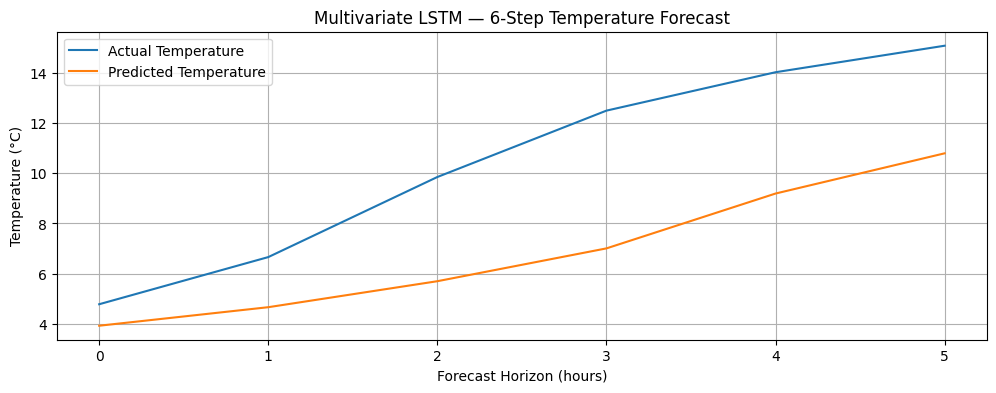

In [60]:
idx = 5  # pick any test sample

plt.figure(figsize=(12,4))
plt.plot(y_test_inv[idx], label="Actual Temperature")
plt.plot(y_pred_inv[idx], label="Predicted Temperature")
plt.title("Multivariate LSTM — 6-Step Temperature Forecast")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

#### Plot Loss Curve

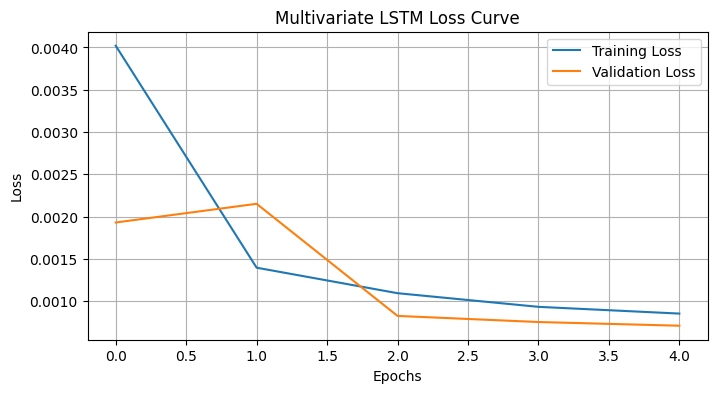

In [61]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Multivariate LSTM Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### <span style="color:blue">05. VAR Benchmark for Multivariate Forecasting

#### Load Dataset & visualize

In [79]:
# Load built-in multivariate dataset
df = sm.datasets.macrodata.load_pandas().data

df.index = pd.date_range(start="1954-01", periods=len(df), freq="Q")
df = df[['realcons', 'realinv', 'realgovt', 'tbilrate', 'realgdp']]

print(df.head())

            realcons  realinv  realgovt  tbilrate   realgdp
1954-03-31    1707.4  286.898   470.045      2.82  2710.349
1954-06-30    1733.7  310.859   481.301      3.08  2778.801
1954-09-30    1751.8  289.226   491.260      3.82  2775.488
1954-12-31    1753.7  299.356   484.052      4.33  2785.204
1955-03-31    1770.5  331.722   462.199      3.50  2847.699


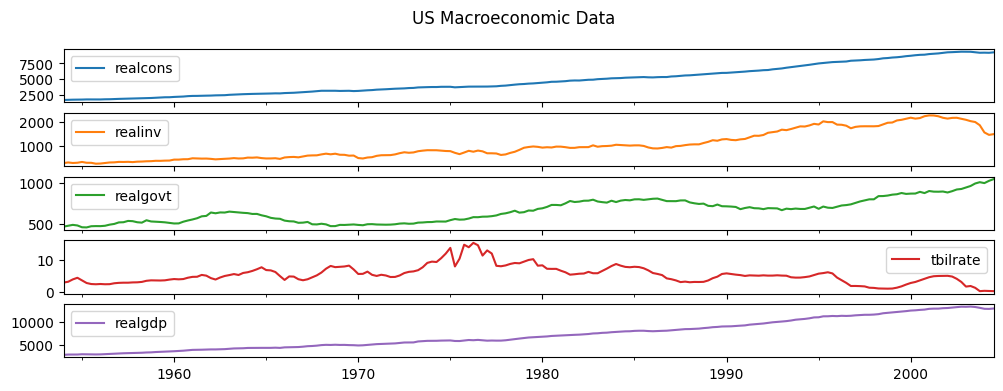

In [80]:
df.plot(subplots=True, figsize=(12, 4))
plt.suptitle("US Macroeconomic Data")
plt.show()

#### Check stationarity & difference the series if needed (VAR requires stationary series)


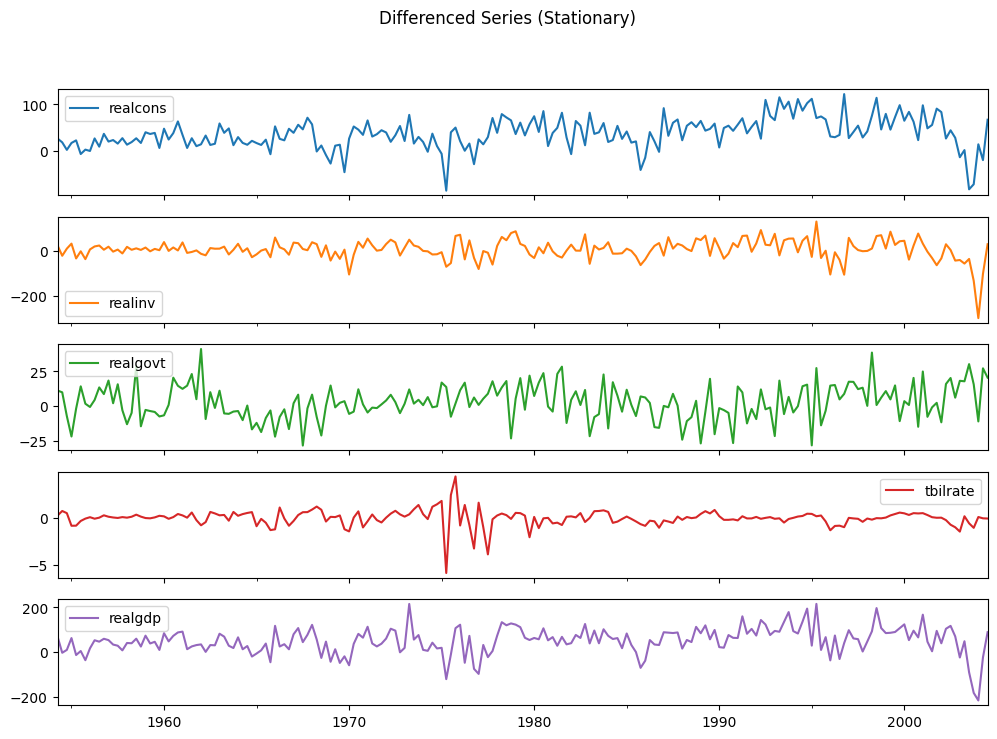

In [81]:
df_diff = df.diff().dropna()

df_diff.plot(subplots=True, figsize=(12, 8))
plt.suptitle("Differenced Series (Stationary)")
plt.show()

#### Fit VAR Model

In [84]:
model = VAR(df_diff)

# Select best lag using AIC
lag_order = model.select_order(maxlags=12)
print("Lag order selection:")
print(lag_order.summary())

p = lag_order.selected_orders['aic']  # choose AIC-minimizing lag

print(f"\nSelected lag order (p) = {p}")

# Fit VAR(p)
var_model = model.fit(p)
print(var_model.summary())

Lag order selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        25.56       25.65   1.264e+11       25.60
1        24.89      25.41*   6.480e+10      25.10*
2        24.88       25.82   6.416e+10       25.26
3       24.77*       26.14  5.752e+10*       25.33
4        24.79       26.59   5.874e+10       25.52
5        24.85       27.07   6.232e+10       25.75
6        24.90       27.55   6.618e+10       25.97
7        24.96       28.03   7.053e+10       26.20
8        24.98       28.49   7.339e+10       26.40
9        25.00       28.93   7.581e+10       26.59
10       25.09       29.45   8.454e+10       26.86
11       25.07       29.86   8.464e+10       27.01
12       25.23       30.44   1.021e+11       27.34
--------------------------------------------------

Selected lag order (p) = 3
  Summary of Regression Results   
Model:                         VAR
Method:       

#### Forecasting

In [85]:
forecast_steps = 8

forecast_input = df_diff.values[-p:]
forecast_diff = var_model.forecast(y=forecast_input, steps=forecast_steps)

# Convert diff forecasts back to level forecasts
forecast_df = pd.DataFrame(forecast_diff, 
                           columns=df.columns,
                           index=pd.date_range(df.index[-1] + pd.offsets.QuarterEnd(), periods=forecast_steps, freq='Q'))

# Restore levels by cumulative sum
last_values = df.iloc[-1]
forecast_levels = forecast_df.cumsum() + last_values

#### Plot VAR Forecast vs Actual

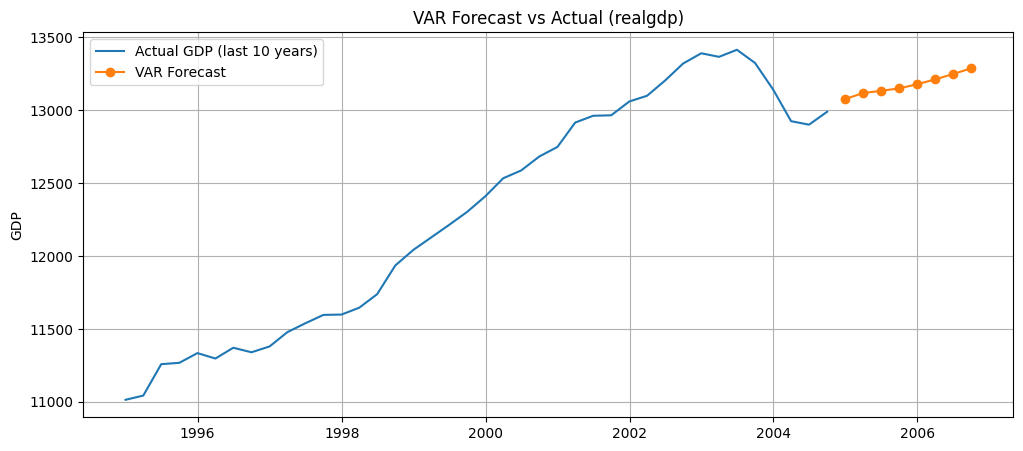

In [86]:
plt.figure(figsize=(12, 5))
plt.plot(df["realgdp"].iloc[-40:], label="Actual GDP (last 10 years)")
plt.plot(forecast_levels["realgdp"], label="VAR Forecast", marker="o")
plt.title("VAR Forecast vs Actual (realgdp)")
plt.ylabel("GDP")
plt.legend()
plt.grid(True)
plt.show()